In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from lifelines import CoxPHFitter
import xgboost as xgb

DATA = Path("../data/processed/tcga_features.csv")
df = pd.read_csv(DATA)
print(f"Loaded {len(df):,} patients")
df["cancer_type"].value_counts()

Loaded 2,662 patients


cancer_type
BRCA    1071
COAD     568
HNSC     522
LUAD     501
Name: count, dtype: int64

In [2]:
def build_xy(df_cancer: pd.DataFrame, min_mut_freq: int = 5):
    """Return X (features), y (sksurv structured array), feature names."""
    gene_cols = [c for c in df_cancer.columns if c.startswith("mut_")]
    freq_genes = [g for g in gene_cols if df_cancer[g].sum() >= min_mut_freq]
    features = ["AGE", "total_mutations"] + freq_genes
    sub = df_cancer[features + ["OS_MONTHS", "event"]].dropna()

    X = sub[features].copy()
    y = Surv.from_dataframe("event", "OS_MONTHS", sub.astype({"event": bool}))
    return X, y, features


def evaluate_survival(name: str, y_test, risk_scores):
    """Censored concordance index."""
    c = concordance_index_censored(y_test["event"], y_test["OS_MONTHS"], risk_scores)
    return {"model": name, "c_index": round(c[0], 3),
            "concordant": int(c[1]), "discordant": int(c[2])}

In [3]:
results = []

for cancer in ["HNSC", "LUAD", "BRCA", "COAD"]:
    sub = df[df["cancer_type"] == cancer].copy()
    if len(sub) < 100:
        continue

    X, y, features = build_xy(sub)
    if len(X) < 50:
        print(f"{cancer}: too few patients after filtering, skipping")
        continue

    # Stratified split on event so test has reasonable death count
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42,
        stratify=[ev for ev in y["event"]],
    )

    print(f"\n=== {cancer} (n_train={len(X_train)}, n_test={len(X_test)}, "
          f"features={len(features)}) ===")

    # --- Model 1: Cox PH baseline (re-fit on train only for fair comparison) ---
    train_df = X_train.copy()
    train_df["OS_MONTHS"] = y_train["OS_MONTHS"]
    train_df["event"]     = y_train["event"].astype(int)
    cph = CoxPHFitter(penalizer=0.05)
    cph.fit(train_df, duration_col="OS_MONTHS", event_col="event")
    risk_cox = cph.predict_partial_hazard(X_test).values
    r1 = evaluate_survival("Cox PH", y_test, risk_cox)

    # --- Model 2: Random Survival Forest ---
    rsf = RandomSurvivalForest(
        n_estimators=200, max_depth=6,
        min_samples_split=10, min_samples_leaf=5,
        n_jobs=-1, random_state=42,
    )
    rsf.fit(X_train, y_train)
    risk_rsf = rsf.predict(X_test)
    r2 = evaluate_survival("Random Survival Forest", y_test, risk_rsf)

    # --- Model 3: XGBoost survival (Cox objective) ---
    # XGBoost expects positive times for events, negative for censored
    y_train_xgb = np.where(y_train["event"], y_train["OS_MONTHS"], -y_train["OS_MONTHS"])
    xgb_clf = xgb.XGBRegressor(
        objective="survival:cox",
        eval_metric="cox-nloglik",
        n_estimators=300, max_depth=4, learning_rate=0.05,
        random_state=42, n_jobs=-1,
    )
    xgb_clf.fit(X_train, y_train_xgb)
    risk_xgb = xgb_clf.predict(X_test)
    r3 = evaluate_survival("XGBoost Survival", y_test, risk_xgb)

    for r in (r1, r2, r3):
        r["cancer"] = cancer
        results.append(r)
        print(f"  {r['model']:<25s} C-index = {r['c_index']:.3f}")

results_df = pd.DataFrame(results)[["cancer", "model", "c_index"]]
results_df


=== HNSC (n_train=391, n_test=131, features=27) ===
  Cox PH                    C-index = 0.574
  Random Survival Forest    C-index = 0.583
  XGBoost Survival          C-index = 0.565

=== LUAD (n_train=368, n_test=123, features=27) ===
  Cox PH                    C-index = 0.491
  Random Survival Forest    C-index = 0.515
  XGBoost Survival          C-index = 0.447

=== BRCA (n_train=803, n_test=268, features=27) ===
  Cox PH                    C-index = 0.595
  Random Survival Forest    C-index = 0.627
  XGBoost Survival          C-index = 0.588

=== COAD (n_train=426, n_test=142, features=29) ===
  Cox PH                    C-index = 0.536
  Random Survival Forest    C-index = 0.617
  XGBoost Survival          C-index = 0.481


,cancer,model,c_index
0,HNSC,Cox PH,0.574
1,HNSC,Random Survival Forest,0.583
2,HNSC,XGBoost Survival,0.565
3,LUAD,Cox PH,0.491
4,LUAD,Random Survival Forest,0.515
5,LUAD,XGBoost Survival,0.447
6,BRCA,Cox PH,0.595
7,BRCA,Random Survival Forest,0.627
8,BRCA,XGBoost Survival,0.588
9,COAD,Cox PH,0.536


In [4]:
pivot = results_df.pivot(index="cancer", columns="model", values="c_index")
print("C-index comparison (higher = better):")
print(pivot)
print()
print("Best model per cancer:")
print(pivot.idxmax(axis=1))

C-index comparison (higher = better):
model   Cox PH  Random Survival Forest  XGBoost Survival
cancer                                                  
BRCA     0.595                   0.627             0.588
COAD     0.536                   0.617             0.481
HNSC     0.574                   0.583             0.565
LUAD     0.491                   0.515             0.447

Best model per cancer:
cancer
BRCA    Random Survival Forest
COAD    Random Survival Forest
HNSC    Random Survival Forest
LUAD    Random Survival Forest
dtype: object


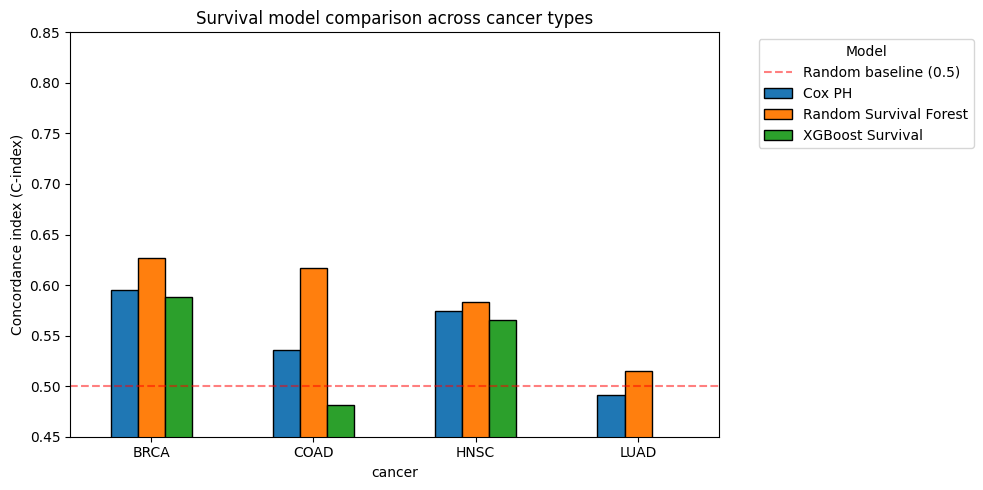

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_ylabel("Concordance index (C-index)")
ax.set_title("Survival model comparison across cancer types")
ax.axhline(0.5, color="red", ls="--", alpha=0.5, label="Random baseline (0.5)")
ax.set_ylim(0.45, max(0.85, pivot.values.max() + 0.05))
ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
import joblib
out = Path("../models")
out.mkdir(exist_ok=True)

best_models = {}
for cancer in pivot.index:
    best_model_name = pivot.loc[cancer].idxmax()
    print(f"{cancer}: best is {best_model_name} (C={pivot.loc[cancer, best_model_name]:.3f})")
    # Train the best model on FULL data and save
    sub = df[df["cancer_type"] == cancer].copy()
    X, y, features = build_xy(sub)
    if best_model_name == "Random Survival Forest":
        m = RandomSurvivalForest(n_estimators=200, max_depth=6,
                                  min_samples_split=10, min_samples_leaf=5,
                                  n_jobs=-1, random_state=42).fit(X, y)
    elif best_model_name == "XGBoost Survival":
        y_xgb = np.where(y["event"], y["OS_MONTHS"], -y["OS_MONTHS"])
        m = xgb.XGBRegressor(objective="survival:cox", eval_metric="cox-nloglik",
                              n_estimators=300, max_depth=4, learning_rate=0.05,
                              random_state=42, n_jobs=-1).fit(X, y_xgb)
    else:  # Cox PH
        train_df = X.copy()
        train_df["OS_MONTHS"] = y["OS_MONTHS"]
        train_df["event"]     = y["event"].astype(int)
        m = CoxPHFitter(penalizer=0.05).fit(train_df,
                                             duration_col="OS_MONTHS",
                                             event_col="event")
    joblib.dump({"model": m, "features": features, "cancer": cancer,
                 "model_type": best_model_name},
                out / f"{cancer}_best_survival_model.joblib")
    best_models[cancer] = (best_model_name, m, features)

print(f"\nSaved {len(best_models)} best models to {out.resolve()}")

BRCA: best is Random Survival Forest (C=0.627)
COAD: best is Random Survival Forest (C=0.617)
HNSC: best is Random Survival Forest (C=0.583)
LUAD: best is Random Survival Forest (C=0.515)

Saved 4 best models to /Users/ammulakshmim.s/Documents/GitHub/tcga-survival-genomics/models
